# Máscara macro, LPS, contornos y vecindad

Inspección de resultados reales. No vuelve a entrenar ni evalúa test. Los scripts de entrenamiento e inferencia se explican en `doc/MEJORAS_MACRO_SOBEL.md`.

**Idea:** primero segmentar las regiones completas; después refinar sus probabilidades y separar fragmentos. Sobel supervisa contornos anatómicos durante entrenamiento. Las alertas de calidad no son diagnósticos.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd()
if not (root / "salidas").exists():
    root = root.parent
folder = root / "salidas/macro_sobel"
data = json.loads((folder / "comparacion.json").read_text(encoding="utf-8"))
rows = []
for name, experiment in data["metrics"].items():
    metric = experiment["refinement"]["0.0"]
    rows.append({"experimento": name, "Dice macro": metric["macro_dice"], "sacro": metric["dice"][0], "coxal izquierdo": metric["dice"][1], "coxal derecho": metric["dice"][2], "mAP50": experiment["base"]["detection"]["mAP50"]})
print(pd.DataFrame(rows).to_string(index=False))
print("Seleccionado:", data["selected"])
print("Comparación de validación; no es test independiente.")

experimento  Dice macro    sacro  coxal izquierdo  coxal derecho    mAP50
    inicial    0.488032 0.239540         0.616616       0.607941 0.526250
    control    0.594495 0.488739         0.630195       0.664551 0.587832
macro_sobel    0.604475 0.526849         0.630055       0.656520 0.638178
Seleccionado: {'model': 'macro_sobel', 'checkpoint': 'salidas/macro_sobel/entrenamiento/best.pth', 'strength': 0.25, 'score': 0.5853375329094819, 'macro_dice': 0.6045372387406732, 'dice': [0.5277384154159075, 0.6298881313145868, 0.6559851694915254], 'eligible': True, 'checkpoint_sha256': 'ae2e052a8310305e6fb498c0a98960f5fd1f4ebdc354668d4126f5cd3ad268b9', 'scope': 'Seleccion y ajuste sobre val; no es evaluacion independiente test', 'seed_min_mm3_3d': 50.0, 'instance_min_mm3_3d': 20.0}
Comparación de validación; no es test independiente.


**Lectura crítica:** buena parte de la mejora de Dice viene del entrenamiento adicional. Macro/Sobel mejora Dice frente al control, pero empeora la métrica específica de contornos. El efecto adicional de la vecindad es mínimo. No interpretar estas cifras como una solución completa de bordes ni de fracturas.

## Geometría
LPS ya estaba implementado. No se cambia solo una etiqueta: SimpleITK reordena los datos y conserva coordenadas físicas. Los headers de test se revisan solo para integridad geométrica; sus máscaras no intervienen en la selección del modelo.

Casos: 100
Orientaciones originales: Counter({'LPS': 66, 'RAS': 34})
Todos alineados: True Geometría válida: True


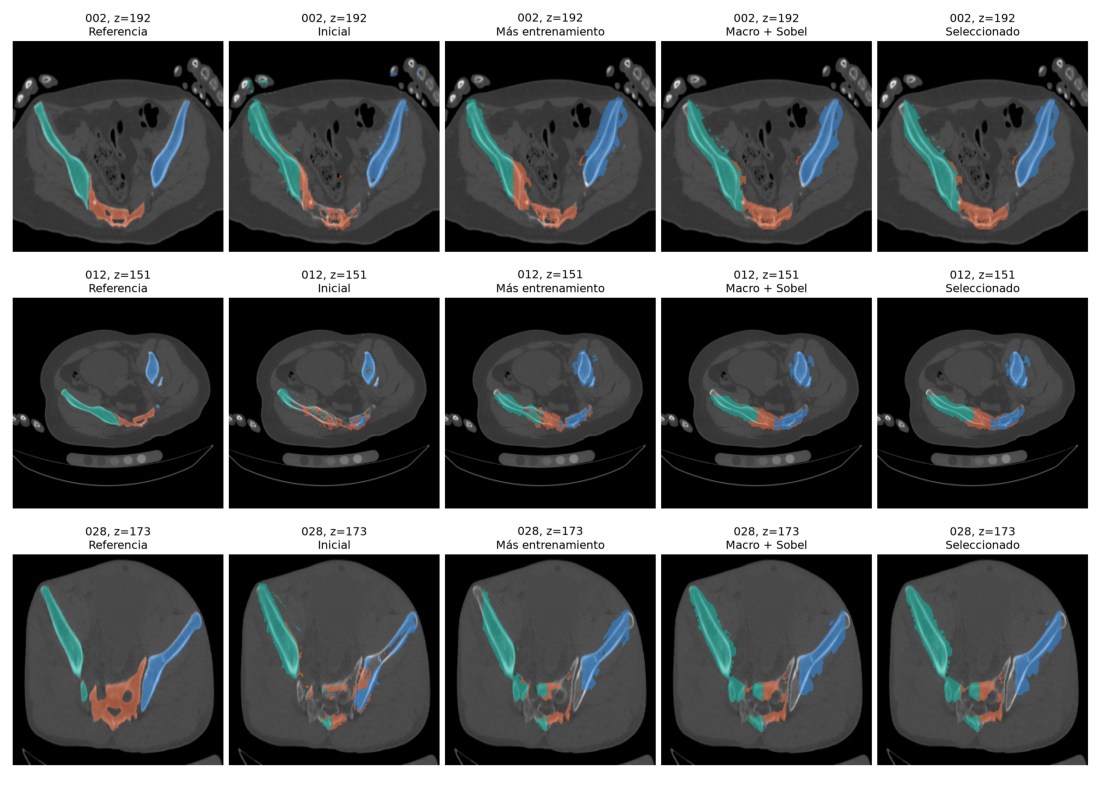

In [2]:
from collections import Counter
geometry = json.loads((folder / "geometria.json").read_text())
print("Casos:", len(geometry["cases"]))
print("Orientaciones originales:", Counter(r["image"]["orientation"] for r in geometry["cases"]))
print("Todos alineados:", geometry["all_aligned"], "Geometría válida:", geometry["all_valid"])
fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(plt.imread(folder / "comparacion.png")); ax.axis("off")
plt.show()

## Comprobación volumétrica
El caso 002 contiene cortes contiguos. Las instancias 2D no equivalen a fragmentos 3D. Una mejora de Dice semántico no demuestra mejora de las distancias. Si MAE es `null`, no hubo pares válidos para calcularlo.

In [3]:
volume = json.loads((folder / "volumenes/002/resumen.json").read_text())
print("Cortes:", volume["slices_contiguous"])
print("Segmentación:", volume["semantic"])
print("Fragmentos y distancias:", volume["fragment_metrics"])
quality = json.loads((folder / "volumenes/002/control_calidad.json").read_text())
print("Control de calidad:", quality)

Cortes: 337
Segmentación: {'dice': [0.5823078581289645, 0.6319138521781693, 0.6801932442073265], 'macro_dice': 0.6314716515048201}
Fragmentos y distancias: {'gt_fragments': 6, 'pred_instances': 96, 'dice_gt_macro_with_misses': 0.32304092691332437, 'iou_gt_macro_with_misses': 0.23850519434160158, 'dice_symmetric_macro_with_unmatched': 0.019778015933468836, 'missed_gt': 2, 'extra_pred': 92, 'distance_comparable_pairs': 0, 'distance_MAE_mm': None}
Control de calidad: {'kind': 'control de calidad, no diagnostico', 'connectivity': 26, 'regions': [{'region': 1, 'components': 155, 'voxels': 226898, 'largest_fraction': 0.9200962547047572}, {'region': 2, 'components': 108, 'voxels': 565493, 'largest_fraction': 0.9555644366950607}, {'region': 3, 'components': 56, 'voxels': 483520, 'largest_fraction': 0.9804144606221046}], 'alerts': ['region_1: mas de 10 componentes; revisar ruido, desconexiones y fracturas', 'region_2: mas de 10 componentes; revisar ruido, desconexiones y fracturas', 'region_3: 